In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)
print("torch version:", torch.__version__)

torch version: 2.9.1


## Data Setup

- Prompt: `"I love paris"`
- 3 outputs, reward only at the last token
- state = prompt + tokens generated so far

| step | state | reward |
|------|-------|--------|
| s0 | I love paris | 0 |
| s1 | I love paris \| I | 0 |
| s2 | I love paris \| I also | 0 |
| s3 | I love paris \| I also love | 0 |
| s4 | terminal (paris generated) | **1.1** |

In [3]:
vocab = {
    "<pad>": 0, "I": 1, "love": 2, "paris": 3,
    "also": 4, "great": 5, "what": 6, "else": 7,
    "you": 8, "nice": 9, "to": 10, "meet": 11,
}
VOCAB_SIZE = len(vocab)

trajectories = [
    {
        "name": "I also love paris",
        "tokens": ["I", "also", "love", "paris"],
        "states": [
            [1, 2, 3],              # s0: prompt only
            [1, 2, 3, 1],           # s1: + I
            [1, 2, 3, 1, 4],        # s2: + also
            [1, 2, 3, 1, 4, 2],     # s3: + love
            [1, 2, 3, 1, 4, 2, 3],  # s4: terminal
        ],
        "rewards": [0.0, 0.0, 0.0, 1.1],
    },
    {
        "name": "great what else you",
        "tokens": ["great", "what", "else", "you"],
        "states": [
            [1, 2, 3],
            [1, 2, 3, 5],
            [1, 2, 3, 5, 6],
            [1, 2, 3, 5, 6, 7],
            [1, 2, 3, 5, 6, 7, 8],
        ],
        "rewards": [0.0, 0.0, 0.0, 0.9],
    },
    {
        "name": "nice to meet you",
        "tokens": ["nice", "to", "meet", "you"],
        "states": [
            [1, 2, 3],
            [1, 2, 3, 9],
            [1, 2, 3, 9, 10],
            [1, 2, 3, 9, 10, 11],
            [1, 2, 3, 9, 10, 11, 8],
        ],
        "rewards": [0.0, 0.0, 0.0, 0.1],
    },
]

print("Trajectories:", [t["name"] for t in trajectories])
print("Rewards:", [t["rewards"] for t in trajectories])

for traj in trajectories:
    for t, token in enumerate(traj["tokens"]):
        print(t, token)
    print('\n')
    


Trajectories: ['I also love paris', 'great what else you', 'nice to meet you']
Rewards: [[0.0, 0.0, 0.0, 1.1], [0.0, 0.0, 0.0, 0.9], [0.0, 0.0, 0.0, 0.1]]
0 I
1 also
2 love
3 paris


0 great
1 what
2 else
3 you


0 nice
1 to
2 meet
3 you




## Critic Network

```
Input: token id sequence (current state as text)
  -> Embedding: vocab_size -> 16 dims per token
  -> Mean Pooling: average all token embeddings -> 1x16
  -> MLP: 16 -> 32 -> 1
Output: V(s), a single scalar
```

> Note: in real LLM PPO, embeddings come from pretrained LLM (not random)

In [4]:
class Critic(nn.Module):
    def __init__(self, vocab_size, embed_dim=16, hidden_dim=32):
        super().__init__()
        # Maps each token id to an embed_dim vector (trainable)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # MLP: maps averaged embedding to scalar V(s)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, token_ids):
        x = torch.tensor(token_ids).unsqueeze(0)  # (1, seq_len)
        emb = self.embedding(x).mean(dim=1)        # (1, embed_dim)
        return self.mlp(emb).squeeze()             # scalar

# Quick test
test_critic = Critic(VOCAB_SIZE)

print("V(s0) initial (random):", test_critic([1]).item())
print("V(s0) initial (random):", test_critic([1,2]).item())
print("V(s0) initial (random):", test_critic([1,2,3]).item())


V(s0) initial (random): -0.11942964792251587
V(s0) initial (random): -0.10875298082828522
V(s0) initial (random): -0.14227592945098877


In [5]:
def print_v_table(critic, label=""):
    sep = "-" * 60
    print(f"\n{sep}")
    print(f"  {label}")
    print(f"{sep}")
    print(f"  {'Trajectory':<22} {'token':<8} {'V(s_t)':>8}    reward")
    print(f"  {sep}")
    for traj in trajectories:
        for t, token in enumerate(traj["tokens"]):
            with torch.no_grad():
                v = critic(traj["states"][t]).item()
            r = traj["rewards"][t]
            marker = "  <- reward here" if r > 0 else ""
            print(f"  {traj['name']:<22} {token:<8} {v:>8.4f}    {r}{marker}")
        print()

## Train Critic

Each training step:
1. Critic predicts `V(s_t)`
2. V(S_t): is the value esitmation of current state (if we follow the current policy - CURRENT POLICY - may not be the optimal one.).
3. Compute TD target:
   - Last step: `target = r_T` (real reward enters here)
   - Middle steps: `target = gamma * V(s_{t+1})` (bootstrapping)
4. `loss = (V(s_t) - target)^2`
5. Backprop, update Critic params

**Watch how reward 1.1 propagates backward epoch by epoch**

In [6]:
def train_critic(n_epochs=500, gamma=1.0, lr=0.01):
    # Initialize Critic with random params
    critic = Critic(VOCAB_SIZE)

    # Adam optimizer — only updates Critic parameters
    optimizer = optim.Adam(critic.parameters(), lr=lr)

    print_v_table(critic, "Before training (V values ~ 0)")

    for epoch in range(n_epochs):
        epoch_loss = 0.0  # accumulate loss across all steps this epoch

        for traj in trajectories:
            states  = traj["states"]   # [s0, s1, s2, s3, s4(terminal)]
            rewards = traj["rewards"]  # [0, 0, 0, 1.1]
            n_steps = len(rewards)     # 4

            for t in range(n_steps):
                # Is this the last generated token?
                is_terminal = (t == n_steps - 1)

                # Critic predicts V(s_t) — requires_grad=True
                v_t = critic(states[t])

                # ── Compute TD target (the "correct answer") ──
                if is_terminal:
                    # Last step: V(s_terminal)=0, so target = r_T
                    # Real reward enters the training signal here
                    td_target = torch.tensor(rewards[t], dtype=torch.float32)
                else:
                    # Middle step: r_t=0, target = gamma * V(s_{t+1})
                    # no_grad: V(s_next) is reference only, not part of gradient
                    # (prevents gradient flowing through target -> unstable training)
                    with torch.no_grad():
                        v_next = critic(states[t + 1])
                    td_target = rewards[t] + gamma * v_next

                # ── Critic loss: pull V(s_t) toward td_target ──
                # MSE: (predicted - target)^2
                loss = (v_t - td_target) ** 2

                # Clear previous gradients (PyTorch accumulates by default)
                optimizer.zero_grad()

                # Backprop: compute gradients of loss w.r.t. all Critic params
                loss.backward()

                # Update Critic params using Adam
                optimizer.step()

                epoch_loss += loss.item()

        # Print V values at key epochs to observe reward propagation
        if epoch + 1 in (1, 10, 50, 100, 200, 500):
            print_v_table(critic, f"Epoch {epoch+1:4d}  Loss={epoch_loss:.4f}")

    return critic


critic = train_critic(n_epochs=500, gamma=1.0, lr=0.01)


------------------------------------------------------------
  Before training (V values ~ 0)
------------------------------------------------------------
  Trajectory             token      V(s_t)    reward
  ------------------------------------------------------------
  I also love paris      I          0.1964    0.0
  I also love paris      also       0.2643    0.0
  I also love paris      love       0.1751    0.0
  I also love paris      paris      0.1395    1.1  <- reward here

  great what else you    great      0.1964    0.0
  great what else you    what       0.1138    0.0
  great what else you    else       0.0273    0.0
  great what else you    you        0.0533    0.9  <- reward here

  nice to meet you       nice       0.1964    0.0
  nice to meet you       to         0.0615    0.0
  nice to meet you       meet       0.0052    0.0
  nice to meet you       you       -0.0025    0.1  <- reward here


------------------------------------------------------------
  Epoch    1  L

## Compute GAE with Trained Critic

```
delta_t = r_t + gamma * V(s_{t+1}) - V(s_t)    <- TD error
A_t = delta_t + gamma*lam * A_{t+1}              <- GAE (backward accumulation)
```

- `delta_t > 0`: this step was better than Critic expected (surprise)
- `delta_t < 0`: worse than expected
- `A_t`: cumulative surprise from step t onward

delta_t vs A_t:

delta_t: this step ws how much better than critic expected (surprise)

A_t: the surpise from this step + the total surprise from all following steps （discounted by lam）

A_0 = delta_0 + λ·delta_1 + λ²·delta_2 + λ³·delta_3


In [7]:
def compute_gae(critic, gamma=1.0, lam=0.95):
    print("\n" + "=" * 60)
    print("  GAE Results (after training)")
    print("=" * 60)

    for traj in trajectories:
        states  = traj["states"]
        rewards = traj["rewards"]
        tokens  = traj["tokens"]
        n = len(rewards)

        # Get V for each state, V(terminal)=0
        V = []
        for t in range(n):
            with torch.no_grad():
                V.append(critic(states[t]).item())
        V.append(0.0)  # V(s_terminal) = 0

        # TD error: delta_t = r_t + gamma*V(s_{t+1}) - V(s_t)
        deltas = [rewards[t] + gamma * V[t+1] - V[t] for t in range(n)]

        # GAE: accumulate backwards (must go backward since A_t depends on A_{t+1})
        advantages = [0.0] * n
        advantages[-1] = deltas[-1]
        for t in reversed(range(n - 1)):
            advantages[t] = deltas[t] + gamma * lam * advantages[t + 1]

        print(f"\n  Trajectory: {traj['name']}")
        print(f"  {'token':<8} {'V(s_t)':>9} {'delta_t':>9} {'Advantage':>12}")
        print(f"  {'-'*42}")
        for t, token in enumerate(tokens):
            print(f"  {token:<8} {V[t]:>9.4f} {deltas[t]:>+9.4f} {advantages[t]:>+12.4f}")


compute_gae(critic)


  GAE Results (after training)

  Trajectory: I also love paris
  token       V(s_t)   delta_t    Advantage
  ------------------------------------------
  I           0.6816   +0.3950      +0.4160
  also        1.0767   +0.0161      +0.0220
  love        1.0928   -0.0124      +0.0062
  paris       1.0804   +0.0196      +0.0196

  Trajectory: great what else you
  token       V(s_t)   delta_t    Advantage
  ------------------------------------------
  great       0.6816   +0.1923      +0.2152
  what        0.8739   +0.0084      +0.0241
  else        0.8823   -0.0050      +0.0165
  you         0.8774   +0.0226      +0.0226

  Trajectory: nice to meet you
  token       V(s_t)   delta_t    Advantage
  ------------------------------------------
  nice        0.6816   -0.5881      -0.5824
  to          0.0936   +0.0014      +0.0060
  meet        0.0950   +0.0003      +0.0048
  you         0.0953   +0.0047      +0.0047


## Visualize: V(s) Propagation Over Training

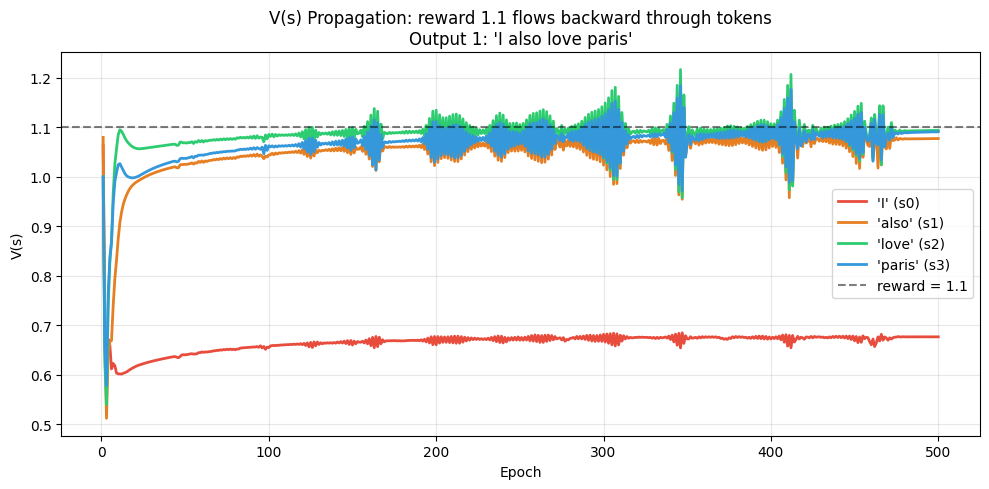

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_v_propagation(n_epochs=500, gamma=1.0, lr=0.01):
    c = Critic(VOCAB_SIZE)
    opt = optim.Adam(c.parameters(), lr=lr)
    traj1 = trajectories[0]
    history = {t: [] for t in range(4)}
    epoch_list = []

    for epoch in range(n_epochs):
        for traj in trajectories:
            states = traj["states"]
            rewards = traj["rewards"]
            for t in range(len(rewards)):
                is_terminal = (t == len(rewards) - 1)
                v_t = c(states[t])
                if is_terminal:
                    td_target = torch.tensor(rewards[t], dtype=torch.float32)
                else:
                    with torch.no_grad():
                        v_next = c(states[t + 1])
                    td_target = rewards[t] + gamma * v_next
                loss = (v_t - td_target) ** 2
                opt.zero_grad()
                loss.backward()
                opt.step()

        epoch_list.append(epoch + 1)
        for t in range(4):
            with torch.no_grad():
                history[t].append(c(traj1["states"][t]).item())

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ["#e74c3c", "#e67e22", "#2ecc71", "#3498db"]
    labels = ["'I' (s0)", "'also' (s1)", "'love' (s2)", "'paris' (s3)"]
    for t in range(4):
        ax.plot(epoch_list, history[t], color=colors[t], label=labels[t], linewidth=2)
    ax.axhline(y=1.1, color="black", linestyle="--", alpha=0.5, label="reward = 1.1")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("V(s)")
    ax.set_title("V(s) Propagation: reward 1.1 flows backward through tokens\nOutput 1: 'I also love paris'")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_v_propagation()

## Final V(s) Comparison Across 3 Trajectories

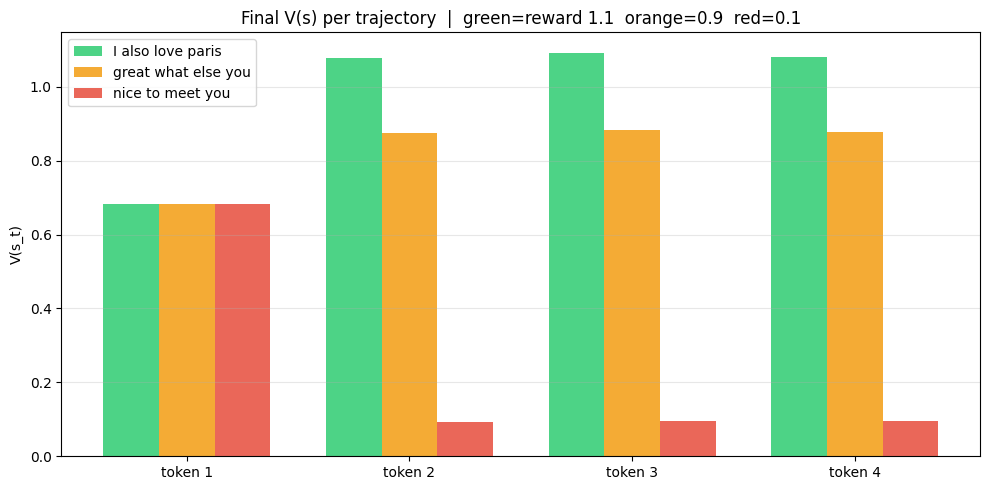


Key observations:
  1. High reward trajectory (1.1): all tokens have high V
  2. Low reward trajectory (0.1): all tokens have low V
  3. Critic learned which path leads to good reward
  4. GAE delta is large where Critic was surprised (not where reward was)


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ecc71", "#f39c12", "#e74c3c"]
x = np.arange(4)
width = 0.25

for i, traj in enumerate(trajectories):
    V_vals = []
    for t in range(4):
        with torch.no_grad():
            V_vals.append(critic(traj["states"][t]).item())
    ax.bar(x + i * width, V_vals, width, label=traj["name"], color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(["token 1", "token 2", "token 3", "token 4"])
ax.set_ylabel("V(s_t)")
ax.set_title("Final V(s) per trajectory  |  green=reward 1.1  orange=0.9  red=0.1")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("  1. High reward trajectory (1.1): all tokens have high V")
print("  2. Low reward trajectory (0.1): all tokens have low V")
print("  3. Critic learned which path leads to good reward")
print("  4. GAE delta is large where Critic was surprised (not where reward was)")

---
## Actor Model

```
Input:  token id sequence (current context / state)
  -> Embedding: vocab_size -> 16
  -> Mean Pooling
  -> MLP: 16 -> 32 -> vocab_size   (logits over all tokens)
  -> Softmax -> probability distribution

Output: P(next_token | context)  for all tokens in vocab
```

Critic 输出一个标量 V(s)
Actor  输出一个向量，每个 token 的生成概率

In [10]:
class Actor(nn.Module):
    def __init__(self, vocab_size, embed_dim=16, hidden_dim=32):
        super().__init__()
        # 同 Critic：每个 token -> embed_dim 向量
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # 和 Critic 的区别：最后一层输出 vocab_size（每个 token 的 logit）
        # Critic 输出 1（标量 V），Actor 输出 vocab_size（概率分布）
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, vocab_size),
        )

    def forward(self, token_ids):
        x   = torch.tensor(token_ids).unsqueeze(0)  # (1, seq_len)
        emb = self.embedding(x).mean(dim=1)          # (1, embed_dim)
        return self.mlp(emb).squeeze(0)              # (vocab_size,) logits

    def get_prob(self, token_ids, action_id):
        """给定 context，返回选择 action_id 这个 token 的概率"""
        logits = self.forward(token_ids)
        probs  = torch.softmax(logits, dim=-1)       # 所有 token 的概率，和为 1
        return probs[action_id]                      # 只取这个动作的概率


# 初始化 Actor（随机参数）
actor = Actor(VOCAB_SIZE)

# 测试：给定 prompt，生成第一个 token 的概率分布
with torch.no_grad():
    logits = actor([1, 2, 3])
    probs  = torch.softmax(logits, dim=-1)

print("给定 'I love paris'，各 token 的初始生成概率：")
for word, idx in vocab.items():
    print(f"  {word:<8} {probs[idx].item():.4f}")

给定 'I love paris'，各 token 的初始生成概率：
  <pad>    0.0667
  I        0.0839
  love     0.0874
  paris    0.0727
  also     0.0813
  great    0.0857
  what     0.1097
  else     0.1182
  you      0.0576
  nice     0.0771
  to       0.0815
  meet     0.0782


## 重新计算 GAE（用训练好的 Critic）

把 Advantage 存成列表，后面 PPO 更新 Actor 时用

In [11]:
def get_advantages(critic, gamma=1.0, lam=0.95):
    """返回 advantages_list[traj_idx][step] = Â_t"""
    advantages_list = []
    for traj in trajectories:
        states  = traj["states"]
        rewards = traj["rewards"]
        n       = len(rewards)

        # 获取每个状态的 V
        V = []
        for t in range(n):
            with torch.no_grad():
                V.append(critic(states[t]).item())
        V.append(0.0)  # V(terminal) = 0

        # δ_t = r_t + γ*V(s_{t+1}) - V(s_t)
        deltas = [rewards[t] + gamma * V[t+1] - V[t] for t in range(n)]

        # GAE 从后往前
        advantages = [0.0] * n
        advantages[-1] = deltas[-1]
        for t in reversed(range(n - 1)):
            advantages[t] = deltas[t] + gamma * lam * advantages[t + 1]

        advantages_list.append(advantages)
    return advantages_list


advantages_list = get_advantages(critic)

print("每个 token 的 Advantage：")
for i, traj in enumerate(trajectories):
    print(f"\n  {traj['name']}")
    for t, token in enumerate(traj["tokens"]):
        print(f"    {token:<8} Â = {advantages_list[i][t]:>+.4f}")

advantages_list[0][1] # means: the first trajectory, and the second token ("also").

每个 token 的 Advantage：

  I also love paris
    I        Â = +0.4160
    also     Â = +0.0220
    love     Â = +0.0062
    paris    Â = +0.0196

  great what else you
    great    Â = +0.2152
    what     Â = +0.0241
    else     Â = +0.0165
    you      Â = +0.0226

  nice to meet you
    nice     Â = -0.5824
    to       Â = +0.0060
    meet     Â = +0.0048
    you      Â = +0.0047


0.02203677588701256

In [15]:
def print_prob_table(actor, label=""):
    sep = "-" * 62
    print(f"\n{sep}")
    print(f"  {label}")
    print(f"{sep}")
    print(f"  {'Trajectory':<22} {'token':<8} {'π(a|s)':>8}   {'Advantage':>10}")
    print(f"  {sep}")
    for i, traj in enumerate(trajectories):
        for t, token in enumerate(traj["tokens"]):
            state     = traj["states"][t] # here the states include the "prompt" and also the "answers"
            action_id = vocab[token]
            with torch.no_grad():
                prob = actor.get_prob(state, action_id).item()
            adv = advantages_list[i][t]
            print(f"  {traj['name']:<22} {token:<8} {prob:>8.4f}   {adv:>+10.4f}")
        print()

print_prob_table(actor, "Actor 初始概率（随机初始化）")


--------------------------------------------------------------
  Actor 初始概率（随机初始化）
--------------------------------------------------------------
  Trajectory             token      π(a|s)    Advantage
  --------------------------------------------------------------
  I also love paris      I          0.1248      +0.4160
  I also love paris      also       0.1276      +0.0220
  I also love paris      love       0.0644      +0.0062
  I also love paris      paris      0.1027      +0.0196

  great what else you    great      0.1259      +0.2152
  great what else you    what       0.1599      +0.0241
  great what else you    else       0.1512      +0.0165
  great what else you    you        0.1294      +0.0226

  nice to meet you       nice       0.0224      -0.5824
  nice to meet you       to         0.1176      +0.0060
  nice to meet you       meet       0.0877      +0.0048
  nice to meet you       you        0.0952      +0.0047



## PPO-Clip Actor 更新

```
① 先记录 π_old（更新前的概率快照）

② for K epochs:
     for each token:
         r_t = π_new(a|s) / π_old(a|s)    ← 新旧概率比
         L_t = min(r_t * Â,  clip(r_t, 1-ε, 1+ε) * Â)
         maximize L_t  →  梯度更新 Actor

Â > 0：r_t 会超过 1（概率上涨），clip 防止涨太猛
Â < 0：r_t 会低于 1（概率下跌），clip 防止跌太猛
```

In [13]:
def ppo_update(actor, advantages_list, n_epochs=10, eps=0.2, lr=1e-2):
    optimizer = optim.Adam(actor.parameters(), lr=lr)

    # ① 记录 π_old（更新前的概率，固定不动）
    # 用 no_grad 因为这只是记录，不需要梯度
    pi_old = {}  # key: (traj_idx, step) -> float
    for i, traj in enumerate(trajectories):
        for t, token in enumerate(traj["tokens"]):
            with torch.no_grad():
                prob = actor.get_prob(traj["states"][t], vocab[token]).item()
            pi_old[(i, t)] = prob

    print_prob_table(actor, "PPO 更新前")

    # ② K 轮 PPO-Clip 更新
    for epoch in range(n_epochs):
        epoch_loss = 0.0

        for i, traj in enumerate(trajectories):
            for t, token in enumerate(traj["tokens"]):
                state     = traj["states"][t]
                action_id = vocab[token]
                adv       = advantages_list[i][t]

                # 当前 Actor 对这个 token 的概率（会随训练变化）
                prob_new = actor.get_prob(state, action_id)

                # 概率比 r_t = π_new / π_old
                # π_old 是固定值（float），不参与梯度
                r_t = prob_new / (pi_old[(i, t)] + 1e-8)

                adv_t = torch.tensor(adv, dtype=torch.float32)

                # PPO-Clip loss（我们要 maximize，所以 minimize 负值）
                unclipped = r_t * adv_t
                clipped   = torch.clamp(r_t, 1 - eps, 1 + eps) * adv_t
                loss      = -torch.min(unclipped, clipped)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()

        if (epoch + 1) % 2 == 0:
            print(f"  Epoch {epoch+1:3d}  loss = {epoch_loss:+.4f}")

    print_prob_table(actor, "PPO 更新后")
    return actor


actor = ppo_update(actor, advantages_list, n_epochs=10, eps=0.2, lr=1e-2)


--------------------------------------------------------------
  PPO 更新前
--------------------------------------------------------------
  Trajectory             token      π(a|s)    Advantage
  --------------------------------------------------------------
  I also love paris      I          0.0839      +0.4160
  I also love paris      also       0.0827      +0.0220
  I also love paris      love       0.0872      +0.0062
  I also love paris      paris      0.0646      +0.0196

  great what else you    great      0.0857      +0.2152
  great what else you    what       0.1046      +0.0241
  great what else you    else       0.1105      +0.0165
  great what else you    you        0.0609      +0.0226

  nice to meet you       nice       0.0771      -0.5824
  nice to meet you       to         0.0904      +0.0060
  nice to meet you       meet       0.0685      +0.0048
  nice to meet you       you        0.0690      +0.0047

  Epoch   2  loss = -0.3961
  Epoch   4  loss = -0.4146
  Epoch   6

## Before / After 对比可视化

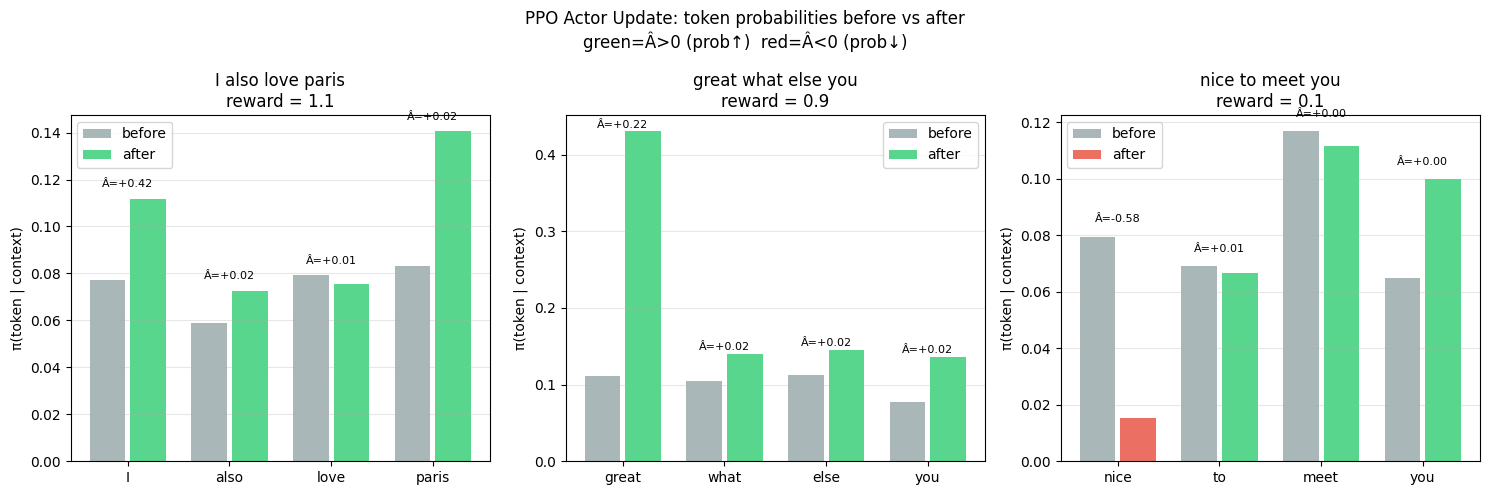


Key observations:
  Â > 0: token prob increased  (model learns to prefer this token)
  Â < 0: token prob decreased  (model learns to avoid this token)
  clip prevents any prob from changing too drastically in one update


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 重新初始化一个 Actor，跑完整对比
actor_fresh = Actor(VOCAB_SIZE)
optimizer   = optim.Adam(actor_fresh.parameters(), lr=1e-2)

# 记录更新前的概率
pi_before = {}
for i, traj in enumerate(trajectories):
    for t, token in enumerate(traj["tokens"]):
        with torch.no_grad():
            pi_before[(i, t)] = actor_fresh.get_prob(traj["states"][t], vocab[token]).item()

# 记录 π_old（和 before 一样，这里是第一轮）
pi_old = dict(pi_before)

# 跑 10 epochs PPO
for epoch in range(10):
    for i, traj in enumerate(trajectories):
        for t, token in enumerate(traj["tokens"]):
            prob_new  = actor_fresh.get_prob(traj["states"][t], vocab[token])
            r_t       = prob_new / (pi_old[(i, t)] + 1e-8)
            adv_t     = torch.tensor(advantages_list[i][t], dtype=torch.float32)
            loss      = -torch.min(r_t * adv_t, torch.clamp(r_t, 0.8, 1.2) * adv_t)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

# 记录更新后的概率
pi_after = {}
for i, traj in enumerate(trajectories):
    for t, token in enumerate(traj["tokens"]):
        with torch.no_grad():
            pi_after[(i, t)] = actor_fresh.get_prob(traj["states"][t], vocab[token]).item()

# ── 画图 ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_before = "#95a5a6"
colors_after  = ["#2ecc71", "#2ecc71", "#2ecc71",
                 "#f39c12", "#f39c12", "#f39c12", "#f39c12",
                 "#e74c3c", "#e74c3c", "#e74c3c", "#e74c3c"]

for i, (traj, ax) in enumerate(zip(trajectories, axes)):
    tokens = traj["tokens"]
    x      = np.arange(len(tokens))
    before = [pi_before[(i, t)] for t in range(len(tokens))]
    after  = [pi_after[(i, t)]  for t in range(len(tokens))]
    advs   = advantages_list[i]

    ax.bar(x - 0.2, before, 0.35, label="before", color=colors_before, alpha=0.8)
    ax.bar(x + 0.2, after,  0.35, label="after",
           color=["#2ecc71" if a > 0 else "#e74c3c" for a in advs], alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(tokens)
    ax.set_ylabel("π(token | context)")
    reward = traj["rewards"][-1]
    ax.set_title(f"{traj['name']}\nreward = {reward}")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    # 标注 advantage
    for t in range(len(tokens)):
        ax.annotate(f"Â={advs[t]:+.2f}", xy=(t, max(before[t], after[t]) + 0.005),
                    ha="center", fontsize=8)

plt.suptitle("PPO Actor Update: token probabilities before vs after\ngreen=Â>0 (prob↑)  red=Â<0 (prob↓)",
             fontsize=12)
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("  Â > 0: token prob increased  (model learns to prefer this token)")
print("  Â < 0: token prob decreased  (model learns to avoid this token)")
print("  clip prevents any prob from changing too drastically in one update")